# Lakh Piano Dataset Statistics
Scans the piano-only file list and computes musical statistics relevant to tokenization decisions.

In [15]:
from pathlib import Path
import numpy as np
import pretty_midi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Walk up from the notebook to find the project root (contains pyproject.toml)
_here = Path.cwd()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / 'pyproject.toml').exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (no pyproject.toml found)")
    PROJECT_ROOT = PROJECT_ROOT.parent

FILE_LIST = PROJECT_ROOT / 'data' / 'lakh_piano_files.txt'
print(f'Project root: {PROJECT_ROOT}')
print(f'File list:    {FILE_LIST}')

Project root: /Users/ryanwilliams/Projects/music-gen
File list:    /Users/ryanwilliams/Projects/music-gen/data/lakh_piano_files.txt


In [16]:
def resolve(p: str) -> Path:
    path = Path(p)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

paths = [resolve(p) for p in FILE_LIST.read_text().splitlines() if p.strip()]
print(f'{len(paths)} files in list')
print(f'Sample: {paths[0]}  exists={paths[0].exists()}')

557 files in list
Sample: /Users/ryanwilliams/Projects/music-gen/data/lakh_clean/Eubie_Blake/Charleston_Rag.mid  exists=True


In [17]:
records = []
failed = []

for i, path in enumerate(paths):
    try:
        pm = pretty_midi.PrettyMIDI(str(path))
        notes = [n for instr in pm.instruments for n in instr.notes]
        if not notes:
            continue

        duration     = pm.get_end_time()                          # seconds
        note_count   = len(notes)
        density      = note_count / duration if duration > 0 else 0
        pitches      = [n.pitch    for n in notes]
        velocities   = [n.velocity for n in notes]
        durations    = [n.end - n.start for n in notes]

        # time gaps between consecutive note onsets (sorted by start)
        onsets       = sorted(n.start for n in notes)
        gaps         = [b - a for a, b in zip(onsets, onsets[1:])]

        # polyphony: average number of notes active at each onset
        poly_counts  = []
        for onset in onsets:
            active = sum(1 for n in notes if n.start <= onset < n.end)
            poly_counts.append(active)

        # large time gaps (> 1s) each require multiple TIME_SHIFT tokens
        large_gaps   = [g for g in gaps if g > 1.0]

        records.append({
            'path':         str(path),
            'duration':     duration,
            'note_count':   note_count,
            'density':      density,
            'pitch_min':    min(pitches),
            'pitch_max':    max(pitches),
            'pitch_mean':   np.mean(pitches),
            'vel_mean':     np.mean(velocities),
            'dur_mean':     np.mean(durations),
            'dur_max':      max(durations),
            'gap_mean':     np.mean(gaps) if gaps else 0,
            'gap_max':      max(gaps) if gaps else 0,
            'large_gap_pct': len(large_gaps) / len(gaps) * 100 if gaps else 0,
            'poly_mean':    np.mean(poly_counts),
            'poly_max':     max(poly_counts),
            # rough token estimate: ~3 tokens per note (VELOCITY + ON + OFF)
            # plus TIME_SHIFT tokens: approx density * duration
            'token_est':    note_count * 3 + len(gaps),
        })
    except Exception as e:
        failed.append((str(path), str(e)))

print(f'Parsed: {len(records)}  Failed: {len(failed)}')

Parsed: 557  Failed: 0


In [18]:
# Diagnose failures
print(f'First 5 failed paths and errors:')
for path, err in failed[:5]:
    print(f'  EXISTS={Path(path).exists()}  {err}')
    print(f'  {path}')
    print()

First 5 failed paths and errors:


In [19]:
def p(label, values, fmt='.1f'):
    a = np.array(values)
    print(f'{label:<30}  mean={a.mean():{fmt}}  median={np.median(a):{fmt}}  min={a.min():{fmt}}  max={a.max():{fmt}}  p95={np.percentile(a,95):{fmt}}')

print('=== FILE-LEVEL STATS ===')
p('Duration (s)',           [r['duration']        for r in records])
p('Note count',             [r['note_count']      for r in records], fmt='.0f')
p('Density (notes/s)',      [r['density']         for r in records])
p('Token estimate',         [r['token_est']       for r in records], fmt='.0f')

print()
print('=== PITCH ===')
p('Pitch mean',             [r['pitch_mean']      for r in records])
p('Pitch min (per file)',   [r['pitch_min']       for r in records], fmt='.0f')
p('Pitch max (per file)',   [r['pitch_max']       for r in records], fmt='.0f')

print()
print('=== NOTE DURATION ===')
p('Note dur mean (s)',      [r['dur_mean']        for r in records])
p('Note dur max (s)',       [r['dur_max']         for r in records])

print()
print('=== TIME GAPS (onset-to-onset) ===')
p('Gap mean (s)',           [r['gap_mean']        for r in records])
p('Gap max (s)',            [r['gap_max']         for r in records])
p('Large gap % (>1s)',      [r['large_gap_pct']   for r in records])

print()
print('=== POLYPHONY ===')
p('Poly mean',              [r['poly_mean']       for r in records])
p('Poly max',               [r['poly_max']        for r in records], fmt='.0f')

print()
total_tokens = sum(r['token_est'] for r in records)
total_dur    = sum(r['duration']  for r in records)
print(f'=== DATASET TOTALS ===')
print(f'  Total duration:       {total_dur/3600:.1f} hours')
print(f'  Total token estimate: {total_tokens:,}')
print(f'  Sequences @ 2048:     {total_tokens // 2048:,}')

=== FILE-LEVEL STATS ===
Duration (s)                    mean=219.2  median=199.1  min=31.4  max=2290.6  p95=394.5
Note count                      mean=1997  median=1612  min=193  max=18054  p95=4202
Density (notes/s)               mean=9.1  median=8.4  min=1.6  max=32.4  p95=16.4
Token estimate                  mean=7986  median=6447  min=771  max=72215  p95=16805

=== PITCH ===
Pitch mean                      mean=62.6  median=62.9  min=47.0  max=79.2  p95=68.1
Pitch min (per file)            mean=30  median=29  min=0  max=52  p95=40
Pitch max (per file)            mean=92  median=93  min=67  max=115  p95=108

=== NOTE DURATION ===
Note dur mean (s)               mean=0.4  median=0.3  min=0.1  max=3.1  p95=0.7
Note dur max (s)                mean=6.6  median=3.1  min=0.5  max=359.3  p95=20.8

=== TIME GAPS (onset-to-onset) ===
Gap mean (s)                    mean=0.1  median=0.1  min=0.0  max=0.6  p95=0.2
Gap max (s)                     mean=1.8  median=1.4  min=0.2  max=15.2  p95=4.

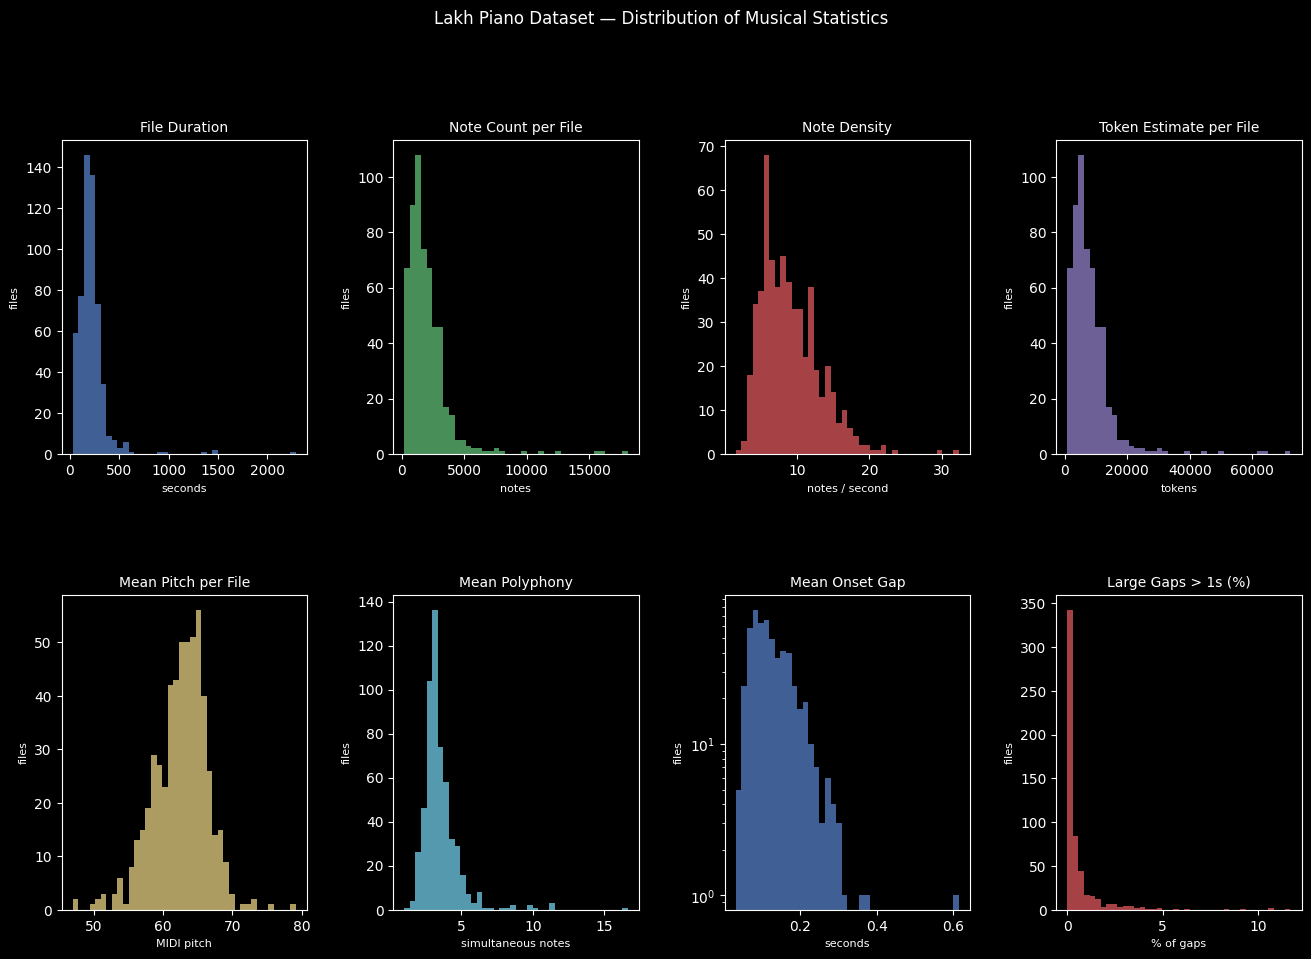

Saved to /Users/ryanwilliams/Projects/music-gen/data/lakh_piano_stats.png


In [20]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

def hist(ax, values, title, xlabel, color, bins=40, log=False):
    ax.hist(values, bins=bins, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('files', fontsize=8)
    if log:
        ax.set_yscale('log')

hist(fig.add_subplot(gs[0, 0]),
     [r['duration'] for r in records],
     'File Duration', 'seconds', '#4C72B0')

hist(fig.add_subplot(gs[0, 1]),
     [r['note_count'] for r in records],
     'Note Count per File', 'notes', '#55A868')

hist(fig.add_subplot(gs[0, 2]),
     [r['density'] for r in records],
     'Note Density', 'notes / second', '#C44E52')

hist(fig.add_subplot(gs[0, 3]),
     [r['token_est'] for r in records],
     'Token Estimate per File', 'tokens', '#8172B2')

hist(fig.add_subplot(gs[1, 0]),
     [r['pitch_mean'] for r in records],
     'Mean Pitch per File', 'MIDI pitch', '#CCB974')

hist(fig.add_subplot(gs[1, 1]),
     [r['poly_mean'] for r in records],
     'Mean Polyphony', 'simultaneous notes', '#64B5CD')

hist(fig.add_subplot(gs[1, 2]),
     [r['gap_mean'] for r in records],
     'Mean Onset Gap', 'seconds', '#4C72B0', log=True)

hist(fig.add_subplot(gs[1, 3]),
     [r['large_gap_pct'] for r in records],
     'Large Gaps > 1s (%)', '% of gaps', '#C44E52')

fig.suptitle('Lakh Piano Dataset — Distribution of Musical Statistics', fontsize=12, y=1.01)
out_path = PROJECT_ROOT / 'data' / 'lakh_piano_stats.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

In [21]:
# Files that will produce very long token sequences (> 10k tokens)
# — worth knowing before deciding on seq_length or whether to cap files
long = sorted(records, key=lambda r: r['token_est'], reverse=True)
print('Top 10 largest files (by token estimate):')
for r in long[:10]:
    print(f"  {Path(r['path']).name:<50}  {r['note_count']:>5} notes  {r['duration']:>6.1f}s  ~{r['token_est']:>6} tokens")

print()
# Files under the minimum threshold
under = [r for r in records if r['token_est'] < 2048]
print(f'Files with < 2048 token estimate: {len(under)} ({len(under)/len(records)*100:.1f}%)')
print('(These will contribute < 1 full training sequence at seq_length=2048)')

Top 10 largest files (by token estimate):
  Clavier-buchlein_fur_Anna_Magdalena_Bach_1725_Aria_G-Dur,_BWV_988_1.mid  18054 notes  2290.6s  ~ 72215 tokens
  Ode_to_Joy_from_the_9th_Symphony.mid                16116 notes  1472.2s  ~ 64463 tokens
  Rhapsody_in_Blue.mid                                15622 notes   924.1s  ~ 62487 tokens
  The_Voice_of_Enigma.mid                             12684 notes  1458.9s  ~ 50735 tokens
  An_American_in_Paris.mid                            10998 notes   950.3s  ~ 43991 tokens
  Pathetique.mid                                       9992 notes  1353.4s  ~ 39967 tokens
  Islamey.mid                                          8086 notes   565.8s  ~ 32343 tokens
  Waltz_from_Faust.mid                                 7697 notes   575.4s  ~ 30787 tokens
  American_Pie.1.mid                                   7345 notes   226.7s  ~ 29379 tokens
  Eleanor_Rigby.mid                                    7220 notes   364.8s  ~ 28879 tokens

Files with < 2048 token es